<h1>Categorical Shift Comparison (Humans vs. LLMs)</h1>

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# initializing high level instances, with config
from preprocessor import Preprocessor
from config_local import config
import pandas as pd
from visualizer import Visualizer
# initializing high level instances, with config
preprocessor = Preprocessor(config=config)
visualizer = Visualizer(config=config)

# parse input files into a merged df
df = preprocessor.get_merged_input_files()


Load LLM dataset

In [3]:
# Load LLM paths dataset
# reference: https://github.com/epfl-ada/ada-2024-project-adaspeedia/blob/main/data/llm_paths_all_gpt4omini_memory.tsv
llm_df = pd.read_csv("data/llm_paths_all_gpt4omini_memory.tsv", sep="\t")

## Data Preprocessing

#### LLMs dataset

In [4]:
# Clean: Remove any path with WRONG_ANSWER or LOOP_DETECTED
llm_df_finished = llm_df[~llm_df['path'].str.contains("WRONG_ANSWER|LOOP_DETECTED")].copy()

# Convert to list of categories for eah path
llm_article_cats_finished = [path.split(";") for path in llm_df_finished['path'].tolist()]

# Print summary and sample
print(f"Number of finished LLM paths: {len(llm_article_cats_finished)}")
print(f"Sample path: {llm_article_cats_finished[0]}")

Number of finished LLM paths: 7557
Sample path: ['Sunset_Boulevard_%281950_film%29', 'Cinema_of_the_United_States', 'California', 'Agriculture']


In [5]:
# LLMs: Categorical shifts per navigatin path
shifts_path_llms, shifts_step_llms = preprocessor.get_shifts_per_path(llm_article_cats_finished)

#### Humans dataset

In [6]:
categories = preprocessor.parse_input_file(config.input_file_categories)

# Only finished paths (perhaps a better idea for the salluviate plot?)
df_finished = df[df["source"] == "finished"].copy()

# Extract the category (final element) and create the article -> category mappings
article_to_cat = (
    categories.assign(cat_short=categories["category"].str.split(".").str[-1])
    .groupby("article")["cat_short"]
    .apply(list)
    .to_dict()
)

# Map all articles in the navigation paths to its first category (mapping missing articles to 'unknown' as there is no category list available)
article_cats = [article_to_cat.get(p, ["Unknown"])[0] for path in df["path"] for p in path.split(";")]
# For finished path (not flattened): used for the  alluviate plot
article_cats_finished = [[article_to_cat.get(p, ["Unknown"])[0] for p in path.split(";")]for path in df_finished["path"]]

In [7]:
# Humans: Categorical shifts per navigatin path
shifts_path_humans, shifts_step_humans = preprocessor.get_shifts_per_path(article_cats_finished)

## Categorical Shifts Comparison

In [8]:
# Compute average categorical shifts per navigation path for Humans
average_shift_humans = preprocessor.get_average_categorical_shifts_path(article_cats_finished)
print(f"Average categorical shift along entire navigation paths (Humans): {average_shift_humans:.3f}")

# Compute average categorical shifts per navigation path for LLMs
average_shift_llms = preprocessor.get_average_categorical_shifts_path(llm_article_cats_finished)
print(f"Average categorical shift along entire navigation paths (LLMs): {average_shift_llms:.3f}")

Average categorical shift along entire navigation paths (Humans): 4.577
Average categorical shift along entire navigation paths (LLMs): 6.985


In [9]:
# Compute proportion of consecutive article pairs (i.e., per navigatio step)  involving a categorical shift for Humans
average_shift_steps_humans = preprocessor.get_average_categorical_shifts_step(article_cats_finished)
print(f"Proportion of consecutive article pairs involving a categorical shift (Humans): {average_shift_steps_humans:.3f}")

# Compute proportion of consecutive article pairs (i.e., per navigatio step) involving a categorical shift for LLMs
average_shift_step_llm = preprocessor.get_average_categorical_shifts_step(llm_article_cats_finished)
print(f"Proportion of consecutive article pairs involving a categorical shift (LLMs): {average_shift_step_llm:.3f}")

Proportion of consecutive article pairs involving a categorical shift (Humans): 0.795
Proportion of consecutive article pairs involving a categorical shift (LLMs): 1.000


### Visualize the average categorical shift comparison

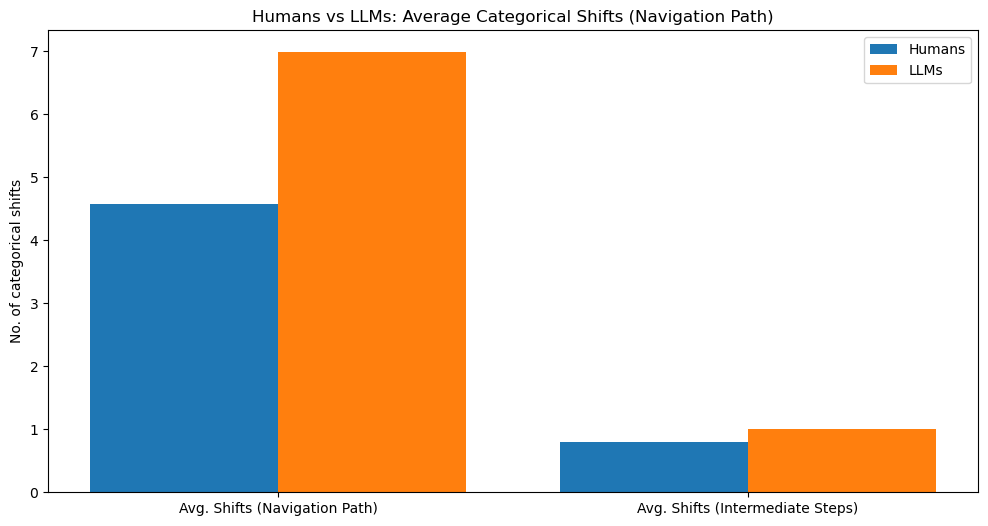

In [10]:
avg_shifts_path = [average_shift_humans, average_shift_steps_humans]                  # Average categorical shifts per navigation path
avg_shifts_step = [average_shift_llms, average_shift_step_llm]                     # Average categorical shifts per navigation step (proportion)
labels = ['Avg. Shifts (Navigation Path)', 'Avg. Shifts (Intermediate Steps)']        # Labels

visualizer.visualize_categorical_shifts_barchart_comparison(avg_shifts_path, avg_shifts_step,labels )

## Categorical Shifts Distributions

### Violin plot of entire distribution

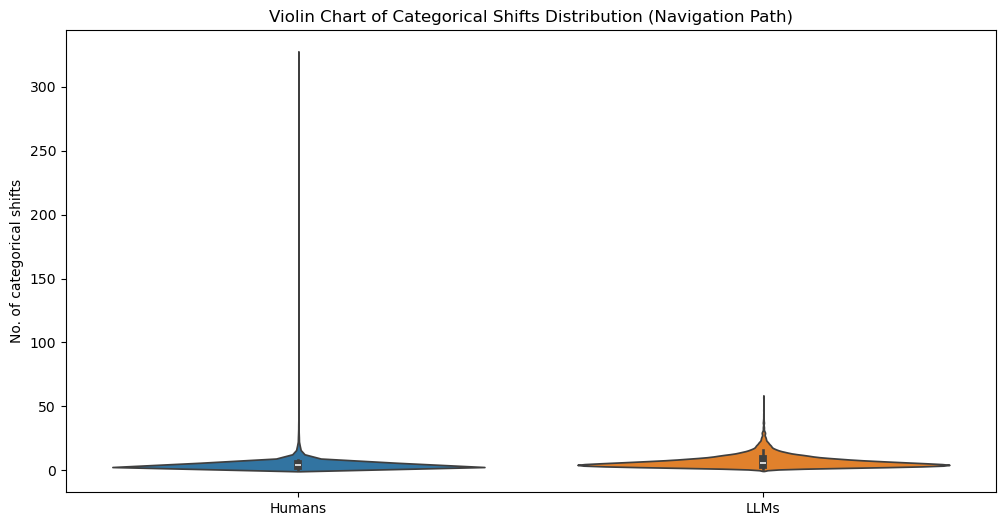

In [11]:
# Labels 
labels = ['Humans', 'LLMs']
visualizer.visualize_categorical_shifts_violin_comparison(shifts_path_humans, shifts_path_llms, labels)

### Violin plot: Zoomed in on the main distribution (i.e. ignoring extreme outliers) for better comparison

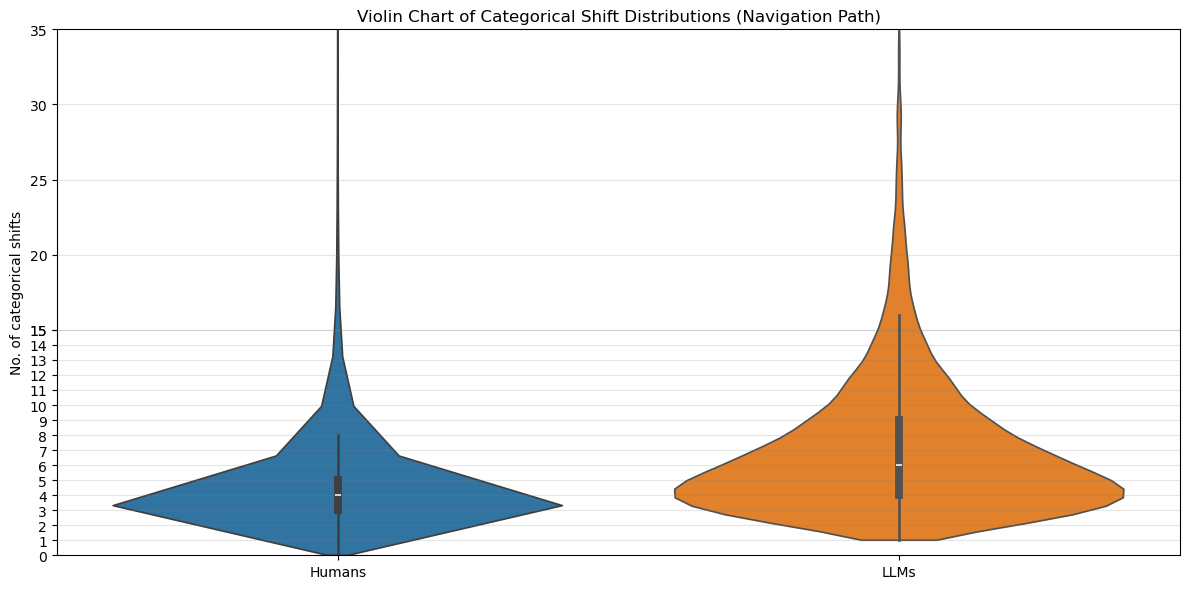

In [12]:
# Plot
visualizer.visualize_categorical_shifts_focuses_violin_comparison(shifts_path_humans, shifts_path_llms, labels)

### Stripplots of the entire distribution

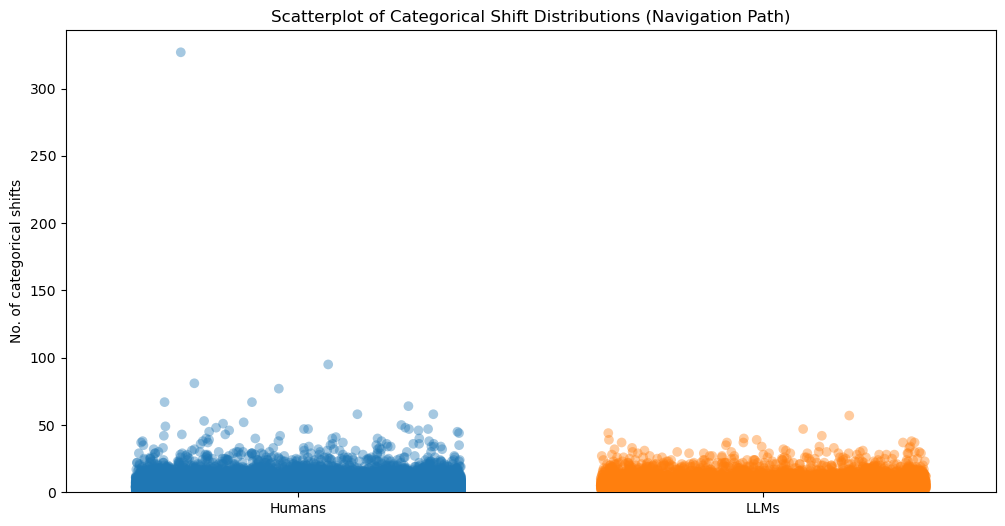

In [13]:
# Combine shift per navigation path for humans and LLMs
human_llm_comp_df = pd.DataFrame({
    'Shifts_per_path': shifts_path_humans + shifts_path_llms,
    'Group': ['Humans']*len(shifts_path_humans) + ['LLMs']*len(shifts_path_llms)
})

# Labels
labels = ['Avg shifts per path', 'Avg shifts per step']      

# Plot
visualizer.visualize_categorical_shifts_scatterplot_comparison(human_llm_comp_df)

### Side-by-side stripplots

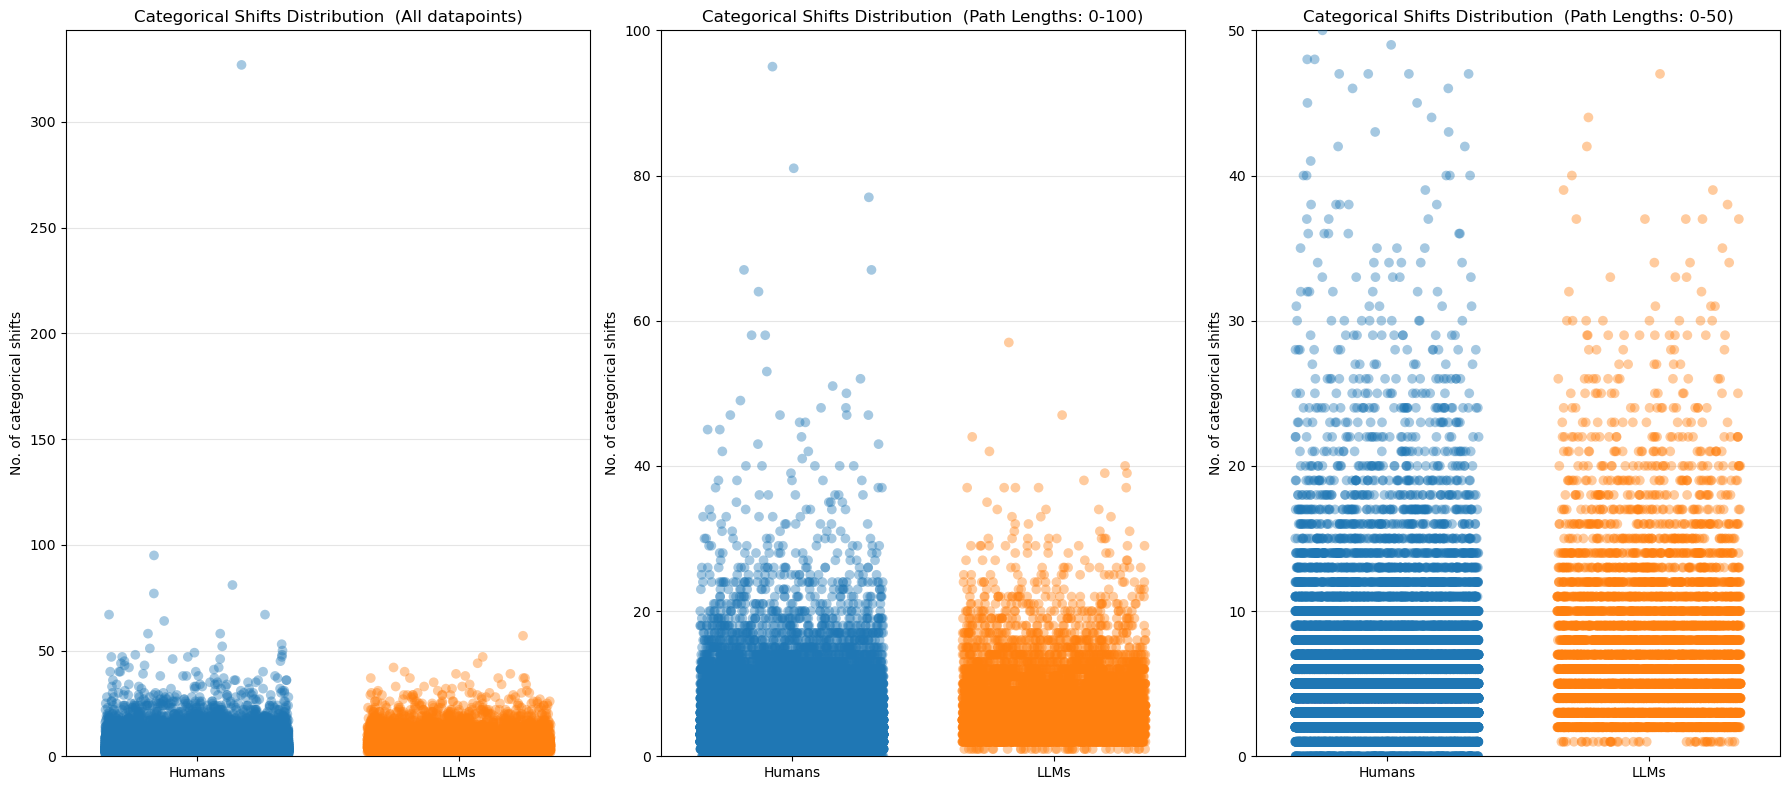

In [14]:
visualizer.visualize_categorical_shifts_scatterplot_sidebyside_comparison(human_llm_comp_df)